# 03. 정책 텍스트마이닝·분석 - Chapter 1~7 범위 조정본


- 텍스트 전처리 결과 불러오기
- 전체·지역별 키워드 빈도 분석
- 지역별 TF-IDF 핵심 키워드 추출
- 정책 분류별 TF-IDF 핵심 키워드 추출
- **TF-IDF 기반 K-means 정책 클러스터링**
- 지역별·분류별 클러스터 분포 시각화

> 이 파일은 1번 전처리 노트북 실행 후 `outputs/policy_preprocessed_solo.csv`를 읽는 것을 기본으로 합니다. 해당 파일이 없으면 같은 폴더의 `youth_policies_categorized.csv`를 읽어 필요한 최소 전처리를 수행합니다.

In [2]:
import re
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans


def get_vectorizer_terms(vectorizer):
    """
    scikit-learn 버전에 따라 단어 목록 추출 함수명이 다르므로
    최신/구버전 모두 동작하도록 처리합니다.
    - 최신 버전: get_feature_names_out()
    - 구버전: get_feature_names()
    """
    if hasattr(vectorizer, "get_feature_names_out"):
        return np.array(vectorizer.get_feature_names_out())
    return np.array(vectorizer.get_feature_names())

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

candidate_paths = [
    OUTPUT_DIR / "policy_scored_solo.csv",
    OUTPUT_DIR / "policy_preprocessed_solo.csv",
    BASE_DIR / "youth_policies_categorized.csv",
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

print("입력 파일:", DATA_PATH)
if DATA_PATH is None:
    raise FileNotFoundError(
        "분석할 정책 CSV가 없습니다. 같은 폴더에 youth_policies_categorized.csv를 두거나, "
        "01번 전처리 노트북을 먼저 실행하세요."
    )

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
print("데이터 크기:", df.shape)
display(df.head())

입력 파일: C:\Users\yong\Desktop\TM\tm2\textmining_solo_policy_project\textmining_solo_policy_project\outputs\policy_scored_solo.csv
데이터 크기: (5470, 61)


,지역,조회_zipCd,정책ID,정책명,정책키워드,정책설명,정책지원내용,정책대분류,정책중분류,자동분류,대표분류,신청기간,사업기간,지원대상,나이조건,소득조건,신청방법,제출서류,주관기관,운영기관,신청URL,참고URL1,참고URL2,최초등록일시,최종수정일시,수집페이지,수집출처,정책ID_정리,정책명_정리,정책명_정제,정책키워드_정제,정책설명_정제,정책지원내용_정제,지원대상_정제,신청방법_정제,주관기관_정제,운영기관_정제,분석텍스트,대표분류_개선,매칭분류_전체,매칭분류수,_최종수정일시_dt,시작일_추정,종료일_추정,상시성정책,신청가능_추정,신청URL_존재,참고URL_존재,신청방법_존재,설명길이,문제대응_고용기회,문제대응_임금소득,문제대응_직무성장,문제대응_워라밸환경,문제대응_주거안정,문제대응_창업생태계,문제대응_참여관계,문제대응_총개수,일자리문제관련정책,정책별_키워드대응점수_raw,정책별_키워드대응점수_100
0,강원,"51000,42000",20260605005400113228,청년미래적금,보조금,"청년들의 기초자산 형성을 지원하기 위한 정책형 금융상품으로, 3년 만기 시까지 매월 최대 50만원 한도 내에서 자유롭게 납입 가능(2026년 6월 22일 출시 예정)","은행이자+비과세 혜택+정부기여금(납입금액에 비례해 일반형 6%, 우대형 12%의 정부기여금 지원)",금융･복지･문화,취약계층 및 금융지원,복지,복지,20260622 ~ 20261231,20260622 ~ 20261231,"19세~34세 / 연령제한:N 0043003 0 0 총급여 7,500만원 이하 또는 연매출 3억원 이하 소상공인 중 가구 중위소득 200% 이하인 청년을 대상 0011009 0013010 0049010 0055003",19세~34세 / 연령제한:N,"0043003 0 0 총급여 7,500만원 이하 또는 연매출 3억원 이하 소상공인 중 가구 중위소득 200% 이하인 청년을 대상",ㅇ 취급은행 모바일앱을 통해 매월 비대면 신청 가능 ㅇ 2026년 6월 출시 예정,NaN,금융위원회,한국고용정보원,NaN,https://www.kinfa.or.kr/financialProduct/youthFutureSavings.do,https://blog.naver.com/blogfsc/224302863400,2026-06-05 18:06:49,2026-06-10 14:05:31,1,온통청년_OPEN_API_getPlcy,20260605005400113228,청년미래적금,청년미래적금,보조금,"청년들의 기초자산 형성을 지원하기 위한 정책형 금융상품으로, 3년 만기 시까지 매월 최대 50만원 한도 내에서 자유롭게 납입 가능(2026년 6월 22일 출시 예정)","은행이자+비과세 혜택+정부기여금(납입금액에 비례해 일반형 6%, 우대형 12%의 정부기여금 지원)","19세~34세 / 총급여 7,500만원 이하 또는 연매출 3억원 이하 소상공인 중 가구 중위소득 200% 이하인 청년을 대상",ㅇ 취급은행 모바일앱을 통해 매월 비대면 신청 가능 ㅇ 2026년 6월 출시 예정,금융위원회,한국고용정보원,"청년미래적금 보조금 청년들의 기초자산 형성을 지원하기 위한 정책형 금융상품으로, 3년 만기 시까지 매월 최대 50만원 한도 내에서 자유롭게 납입 가능(2026년 6월 22일 출시 예정) 은행이자+비과세 혜택+정부기여금(납입금액에 비례해 일반형 ...",창업지원,"복지, 일자리, 창업지원, 참여 프로그램",4,2026-06-10 14:05:31,2026-06-22 00:00:00,2026-12-31 00:00:00,0,1,0,1,1,288,1,1,0,0,0,1,1,4,1,0.56,100.0
1,강원,"51000,42000",20250114005400210229,스마트 모빌리티 창업캠프사업,교육지원,"미래모빌리티 분야 창업을 희망하는 청년을 대상으로 국내 자동차업계 마이스터들의 강연, 멘토링, 카운슬링을 지원하여 창업아이디어를 구체화하고 창업 준비를 위한 각종 프로그램 운영","1. (사전프로그램) 기업가정신 함양, 멘토링, 카운슬링 2. (집합프로그램) - 자동차산업 전망, 창업 핵심기반, 기업가정신 등 교육지원 - 창업아이디어 도출･평가, 개발 제품 설계･평가 지원 등 실습 - 대한민국 미래모빌리티엑스포 연계, 창...","일자리,일자리","취업,창업","일자리, 직무교육, 창업지원, 참여 프로그램",일자리,20260401 ~ 20260528,20260301 ~ 20261231,"0세~0세 / 연령제한:Y 0043001 0 0 모빌리티 분야(관련) 전공 대학(원)생 0011003,0011004,0011005 0013010 0049005,0049006,0049007,0049008 0055003",0세~0세 / 연령제한:Y,0043001 0 0,공고에 따라 지원서 작성 후 이메일 제출(신청기간 연장~5/28),대학생 스마트 모빌리티 창업캠프 지원서,미래모빌리티과,대구광역시 미래혁신성장실,https://www.kaae.kr/,https://www.kaae.kr/,NaN,2025-01-14 11:00:54,2026-05-29 14:57:57,5,온통청년_OPEN_API_getPlcy,20250114005400210229,스마트 모빌리티 창업캠프사업,스마트 모빌리티 창업캠프사업,교육지원,"미래모빌리티 분야 창업을 희망하는 청년을 대상으로 국내 자동차업계 마이스터들의 강연, 멘토링, 카운슬링을 지원하여 창업아이디어를 구체화하고 창업 준비를 위한 각종 프로그램 운영","1. (사전프로그램) 기업가정신 함양, 멘토링, 카운슬링 2. (집합프로그램) - 자동차산업 전망, 창업 핵심기반, 기업가정신 등 교육지원 - 창업아이디어 도출･평가, 개발 제품 설계･평가 지원 등 실습 - 대한민국 미래모빌리티엑스포 연계, 창...","0세~0세 / 모빌리티 분야(관련) 전공 대학(원)생 , , , , ,",공고에 따라 지원서 작성 후 이메일 제출(신청기간 연장~5/28),미래모빌리티과,대구광역시 미래혁신성장실,"스마트 모빌리티 창업캠프사업 교육지원 미래모빌리티 분야 창업을 희망하는 청년을 대상으로 국내 자동차업계 마이스터들의 강연, 멘토링, 카운슬링을 지원하여 창업아이디어를 구체화하고 창업 준비를 위한 각종 프로그램 운영 1. (사전프로그램) 기업가정...",창업지원,"창업지원, 직무교육, 일자리, 참여 프로그램",4,2026-05-29 14:57:57,2026-03-01 00:00:00,2026-12-31 00:00:00,0,1,1,1,1,400,0,0,1,0,0,1,0,2,1,0.28,100.0
2,강원,"51000,42000",20250714005400111227,산림산업 창업지원_청년 임팩트 창업 아이디어 챌린지,"교육지원,맞춤형상담서비스,장기미취업청년",산림자원을 활용 기반의 산림 문제 해결형 사업 공모전 개최 및 실증 과정을 통한 청년 창업 경험 지원,ㅇ 공모전명 : 2026 청년 林팩트 창업 아이디어 챌린지 ㅇ 주요내용 : 산림자원을 활용 기반의 산림 문제 해결형 사업 공모전 개최 및 실증 과정을 통한 청년 창업 경험 지원 ㅇ 일 정 : 2026.6.22.(월) ~ 6.23(화) / [참가...,"일자리,일자리","취업,창업","일자리, 직무교육, 창업지원, 복지, 참여 프로그램",일자리,20260520 ~ 20260603,20260622 ~ 20260623,19세~39세 / 연령제한:N 0043001 0 0 산림창업에 관심있는 청년(만19세 ~ 39세) 누구나 0011009 0013010 0049010 0055003,19세~39세 / 연령제한:N,0043001 0 0,NaN,1. 신청사이트 URL을 통하여 참가신청서 작성 2. 한국임업진흥원 누리집(www.kofpi.or.kr)의 ‘알림/홍보’ - ‘공지사항’ 메뉴 '청년 임팩트 창업 아이디어 챌린지' 게시판의 참가신청 큐알(QR) 코드 또는 링크(https://d...,산림청,한국임업진흥원,https://docs.google.com/forms/u/0/d/1-QTMyaKxeBcQvtNYkMlNIkhtZ-K1lxyVEBMDn9WsAuo/viewform?edit_requested=true,www.kofpi.or.kr,NaN,2025-07-14 22:19:33

## 1. 한글 폰트 설정 및 분석 텍스트 준비

1번 전처리 파일을 실행했다면 `분석텍스트_정제`, `token_text` 컬럼을 그대로 사용합니다.  
전처리 결과가 없고 원본 CSV만 있는 경우에는 정책명, 정책키워드, 정책설명, 정책지원내용 등을 결합해 분석 텍스트를 새로 만듭니다.

In [3]:
import matplotlib.font_manager as fm

available_fonts = {f.name for f in fm.fontManager.ttflist}
for font in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "DejaVu Sans"]:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break
plt.rcParams["axes.unicode_minus"] = False
print("사용 폰트:", plt.rcParams["font.family"])

TEXT_COL_CANDIDATES = [
    "정책명", "정책키워드", "정책설명", "정책지원내용", "지원대상", "신청방법", "주관기관", "운영기관"
]

STOPWORDS_TEXT = """
청년 정책 지원 사업 대상 신청 제공 해당 통해 대한 관련 경우 가능 추진 운영 진행 모집 선정 지급 이용 위한 또는 그리고 등 및 에서 으로 하는 하여 있다 있는
지역 서울 경기 강원 충북 충남 전북 전남 경북 경남 제주
연령 제한 기준 이하 이상 해당자 신청자 지원자 참여자 대상자 사업자 기관 센터 홈페이지 온라인 방문 전화 문의
내용 방법 기간 사업명 사업내용 지원내용 정책명 정책설명 정책키워드
"""
STOPWORDS = set(STOPWORDS_TEXT.split())
STOPWORDS.update(["0043003", "0011009", "0013010", "0049010", "0055003", "nan", "none"])


def clean_policy_text(text):
    """정규표현식 기반 간단 텍스트 정제."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&[a-zA-Z]+;", " ", text)
    text = re.sub(r"연령제한\s*:\s*[YN]", " ", text)
    text = re.sub(r"\b\d{5,7}\b", " ", text)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def simple_korean_tokenizer(text):
    """2글자 이상 한글/영문 중심 토큰화. 형태소 분석기를 쓰지 않는 수업 범위 내 간단 토큰화."""
    text = clean_policy_text(text)
    tokens = re.findall(r"[가-힣]{2,}|[a-zA-Z]{2,}|\d{2,}", text)
    tokens = [t.lower() for t in tokens]
    tokens = [t for t in tokens if t not in STOPWORDS]
    tokens = [t for t in tokens if not t.isdigit()]
    return tokens

# 분석 텍스트가 없으면 원본 컬럼을 결합해서 생성
if "분석텍스트_정제" not in df.columns:
    existing_text_cols = [c for c in TEXT_COL_CANDIDATES if c in df.columns]
    if not existing_text_cols:
        raise ValueError("분석에 사용할 텍스트 컬럼을 찾지 못했습니다.")
    df["분석텍스트"] = df[existing_text_cols].fillna("").astype(str).agg(" ".join, axis=1)
    df["분석텍스트_정제"] = df["분석텍스트"].apply(clean_policy_text)

# 토큰 컬럼 생성
if "token_text" not in df.columns:
    df["tokens"] = df["분석텍스트_정제"].apply(simple_korean_tokenizer)
    df["token_text"] = df["tokens"].apply(lambda x: " ".join(x))
else:
    # token_text가 이미 있더라도 이후 빈도 분석용 tokens는 다시 생성
    df["tokens"] = df["token_text"].fillna("").apply(lambda x: str(x).split())

# 분류 컬럼 선택
category_col = None
for c in ["대표분류_개선", "대표분류", "자동분류", "정책중분류", "정책대분류"]:
    if c in df.columns:
        category_col = c
        break
if category_col is None:
    df["분류_분석"] = "미분류"
    category_col = "분류_분석"

# 지역 컬럼 보정
if "지역" not in df.columns:
    df["지역"] = "미상"

df["token_count"] = df["tokens"].apply(len)
print("분석 분류 컬럼:", category_col)
print("토큰 수 요약")
display(df["token_count"].describe())
display(df[["지역", category_col, "정책명", "token_text"]].head())

사용 폰트: ['Malgun Gothic']
분석 분류 컬럼: 대표분류_개선
토큰 수 요약


count    5470.000000
mean       64.564351
std        50.280760
min        11.000000
25%        33.000000
50%        49.000000
75%        80.000000
max       414.000000
Name: token_count, dtype: float64

,지역,대표분류_개선,정책명,token_text
0,강원,창업지원,청년미래적금,청년미래적금 보조금 청년들의 기초자산 형성을 지원하기 정책형 금융상품으로 만기 시까지 매월 최대 만원 한도 내에서 자유롭게 납입 출시 예정 은행이자 비과세 혜택 정부기여금 납입금액에 비례해 일반형 우대형 정부기여금 총급여 만원 연매출 억원 소상...
1,강원,창업지원,스마트 모빌리티 창업캠프사업,스마트 모빌리티 창업캠프사업 교육지원 미래모빌리티 분야 창업을 희망하는 청년을 대상으로 국내 자동차업계 마이스터들의 강연 멘토링 카운슬링을 지원하여 창업아이디어를 구체화하고 창업 준비를 각종 프로그램 사전프로그램 기업가정신 함양 멘토링 카운슬링...
2,강원,창업지원,산림산업 창업지원_청년 임팩트 창업 아이디어 챌린지,산림산업 창업지원 임팩트 창업 아이디어 챌린지 교육지원 맞춤형상담서비스 장기미취업청년 산림자원을 활용 기반의 산림 문제 해결형 공모전 개최 실증 과정을 통한 창업 경험 공모전명 팩트 창업 아이디어 챌린지 주요내용 산림자원을 활용 기반의 산림 문...
3,강원,일자리,(농식품부) 농식품 바우처,농식품부 농식품 바우처 바우처 농업 농촌 식품산업 기본법 조의 취약계층 등에 식품지원 근거하여 취약계층의 식품 접근성을 강화하고 균형 식품 섭취를 지원하는 식품지원 제도 지원방식 전자바우처 카드방식 지원품목 국산 채소류 과일류 육류 신선알류 우...
4,강원,일자리,삼척형 청년인턴 지원사업,삼척형 청년인턴 지원사업 인턴 삼척시 거주 미취업 공공 행정 분야 인턴 연수 기회 하반기 행정인턴 근무 시간 선발 우선순위 모집인원 초과 취약계층 기초생활수급자 차상위계층 한부모가정 국가유공자 단계 행복일자리 청년층 행정인턴 선발기준표에 의한 ...


## 2. 전체·지역별 키워드 빈도 분석

단어가 텍스트에서 얼마나 자주 나타나는지 확인합니다. 이는 교재의 카운트 기반 문서 표현과 텍스트 시각화 흐름에 해당합니다.

,키워드,빈도
0,만원,3167
1,프로그램,2029
2,교육지원,1973
3,교육,1587
4,개월,1489
5,참여,1414
6,최대,1387
7,통한,1314
8,보조금,1283
9,대학,1066


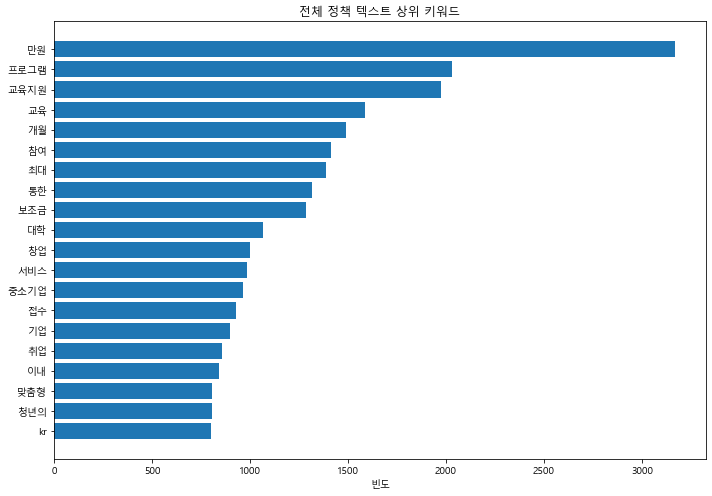

,지역,순위,키워드,빈도
0,강원,1,만원,278
1,강원,2,프로그램,190
2,강원,3,교육지원,178
3,강원,4,개월,152
4,강원,5,참여,143
5,강원,6,교육,143
6,강원,7,최대,124
7,강원,8,보조금,117
8,강원,9,강원특별자치도,116
9,강원,10,통한,112


In [4]:
all_tokens = [tok for tokens in df["tokens"] for tok in tokens]
if len(all_tokens) == 0:
    raise ValueError("추출된 토큰이 없습니다. 전처리 단계와 텍스트 컬럼을 확인하세요.")

overall_freq = pd.DataFrame(Counter(all_tokens).most_common(100), columns=["키워드", "빈도"])
display(overall_freq.head(30))
overall_freq.to_csv(OUTPUT_DIR / "overall_keyword_frequency_solo.csv", index=False, encoding="utf-8-sig")

plot_df = overall_freq.head(20).sort_values("빈도", ascending=True)
plt.figure(figsize=(10, 7))
plt.barh(plot_df["키워드"], plot_df["빈도"])
plt.title("전체 정책 텍스트 상위 키워드")
plt.xlabel("빈도")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "overall_top_keywords_solo.png", dpi=200)
plt.show()

region_keyword_rows = []
for region, g in df.groupby("지역"):
    tokens = [tok for ts in g["tokens"] for tok in ts]
    counter = Counter(tokens)
    for rank, (keyword, freq) in enumerate(counter.most_common(30), start=1):
        region_keyword_rows.append({"지역": region, "순위": rank, "키워드": keyword, "빈도": freq})

region_keyword_freq = pd.DataFrame(region_keyword_rows)
display(region_keyword_freq.head(60))
region_keyword_freq.to_csv(OUTPUT_DIR / "region_keyword_frequency_solo.csv", index=False, encoding="utf-8-sig")

## 3. 지역별 TF-IDF 핵심 키워드

지역별 정책 문서를 하나의 문서로 묶은 뒤 TF-IDF를 적용합니다. 단순 빈도보다 특정 지역에서 상대적으로 두드러지는 키워드를 찾는 데 사용합니다.

In [5]:
region_docs = (
    df.groupby("지역")["token_text"]
    .apply(lambda x: " ".join(x.dropna().astype(str)))
    .reset_index()
)

region_vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b", min_df=1, max_df=0.95)
X_region = region_vectorizer.fit_transform(region_docs["token_text"])
region_terms = get_vectorizer_terms(region_vectorizer)

region_tfidf_rows = []
for i, region in enumerate(region_docs["지역"]):
    row = X_region[i].toarray().ravel()
    top_idx = row.argsort()[::-1][:30]
    for rank, idx in enumerate(top_idx, start=1):
        if row[idx] > 0:
            region_tfidf_rows.append({
                "지역": region,
                "순위": rank,
                "키워드": region_terms[idx],
                "TFIDF": round(float(row[idx]), 6),
            })

region_tfidf = pd.DataFrame(region_tfidf_rows)
display(region_tfidf.head(80))
region_tfidf.to_csv(OUTPUT_DIR / "region_tfidf_keywords_solo.csv", index=False, encoding="utf-8-sig")

,지역,순위,키워드,TFIDF
0,강원,1,원주시,0.665539
1,강원,2,춘천시,0.285231
2,강원,3,삼척시,0.213923
3,강원,4,고성군,0.202039
4,강원,5,경제진흥국,0.130731
...,...,...,...,...
75,경남,16,농업용드론,0.048980
76,경남,17,경남도내,0.048980
77,경남,18,민생경제과,0.048980
78,경남,19,고독사,0.048980


## 4. 정책 분류별 TF-IDF 핵심 키워드

정책 분류별로 텍스트를 묶고 TF-IDF를 계산하여, 각 정책 분야를 대표하는 핵심 키워드를 확인합니다.

In [6]:
category_docs = (
    df.groupby(category_col)["token_text"]
    .apply(lambda x: " ".join(x.dropna().astype(str)))
    .reset_index()
    .rename(columns={category_col: "분류"})
)

cat_vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b", min_df=1, max_df=0.95)
X_cat = cat_vectorizer.fit_transform(category_docs["token_text"])
cat_terms = get_vectorizer_terms(cat_vectorizer)

category_tfidf_rows = []
for i, category in enumerate(category_docs["분류"]):
    row = X_cat[i].toarray().ravel()
    top_idx = row.argsort()[::-1][:30]
    for rank, idx in enumerate(top_idx, start=1):
        if row[idx] > 0:
            category_tfidf_rows.append({
                "분류": category,
                "순위": rank,
                "키워드": cat_terms[idx],
                "TFIDF": round(float(row[idx]), 6),
            })

category_tfidf = pd.DataFrame(category_tfidf_rows)
display(category_tfidf.head(100))
category_tfidf.to_csv(OUTPUT_DIR / "category_tfidf_keywords_solo.csv", index=False, encoding="utf-8-sig")

,분류,순위,키워드,TFIDF
0,복지,1,이후,0.194802
1,복지,2,서비스,0.168043
2,복지,3,보호종료,0.157653
3,복지,4,서울청년센터,0.137052
4,복지,5,바우처,0.133792
...,...,...,...,...
95,직무교육,6,ai,0.110742
96,직무교육,7,인턴,0.105579
97,직무교육,8,맞춤형,0.100052
98,직무교육,9,서비스,0.096219


## 5. TF-IDF 기반 K-means 정책 클러스터링

LDA 토픽모델링 대신 교재 Chapter 7의 클러스터링 흐름에 맞춰 K-means를 사용합니다.

분석 절차는 다음과 같습니다.

1. 정책별 `token_text`를 TF-IDF 특징 벡터로 변환
2. K-means로 유사한 정책 문서를 군집화
3. 각 군집의 중심값이 큰 단어를 대표 키워드로 추출
4. 지역별·분류별 클러스터 분포를 비교

`N_CLUSTERS` 값은 기본 6개로 설정했지만, 결과 해석이 어렵다면 5~8 사이에서 조정할 수 있습니다.

In [7]:
# 너무 짧은 문서는 클러스터링 품질을 떨어뜨릴 수 있어 제외하지 않고 빈 텍스트만 제거합니다.
cluster_df = df[df["token_text"].fillna("").str.strip().ne("")].copy().reset_index(drop=True)
print("클러스터링 대상 정책 수:", len(cluster_df))

N_CLUSTERS = 6
if len(cluster_df) < N_CLUSTERS:
    N_CLUSTERS = max(2, len(cluster_df))

cluster_vectorizer = TfidfVectorizer(
    token_pattern=r"(?u)\b\w+\b",
    min_df=3,
    max_df=0.85,
    max_features=3000,
)
X_policy = cluster_vectorizer.fit_transform(cluster_df["token_text"])
cluster_terms = get_vectorizer_terms(cluster_vectorizer)
print("TF-IDF 행렬 크기:", X_policy.shape)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_policy)
cluster_df["KMeans클러스터"] = cluster_labels + 1

# 원본 df에도 클러스터 번호 병합
# cluster_df는 reset_index를 했으므로 원본 인덱스를 보존하기 위해 별도 키를 사용합니다.
df["_row_id"] = np.arange(len(df))
cluster_df["_row_id"] = df[df["token_text"].fillna("").str.strip().ne("")]["_row_id"].values
df = df.merge(cluster_df[["_row_id", "KMeans클러스터"]], on="_row_id", how="left")
df.drop(columns=["_row_id"], inplace=True)

cluster_size = (
    cluster_df["KMeans클러스터"]
    .value_counts()
    .sort_index()
    .rename_axis("KMeans클러스터")
    .reset_index(name="정책수")
)
display(cluster_size)
cluster_size.to_csv(OUTPUT_DIR / "kmeans_cluster_size_solo.csv", index=False, encoding="utf-8-sig")

클러스터링 대상 정책 수: 5470
TF-IDF 행렬 크기: (5470, 3000)


,KMeans클러스터,정책수
0,1,460
1,2,2268
2,3,159
3,4,1032
4,5,1211
5,6,340


## 6. 클러스터별 대표 키워드와 대표 정책 확인

In [8]:
N_TOP_WORDS = 15
cluster_keyword_rows = []
centers = kmeans.cluster_centers_

for cluster_idx in range(N_CLUSTERS):
    top_idx = centers[cluster_idx].argsort()[::-1][:N_TOP_WORDS]
    keywords = cluster_terms[top_idx]
    for rank, term_idx in enumerate(top_idx, start=1):
        cluster_keyword_rows.append({
            "KMeans클러스터": cluster_idx + 1,
            "순위": rank,
            "대표키워드": cluster_terms[term_idx],
            "중심값": round(float(centers[cluster_idx, term_idx]), 6),
        })

cluster_keywords = pd.DataFrame(cluster_keyword_rows)
display(cluster_keywords.head(100))
cluster_keywords.to_csv(OUTPUT_DIR / "kmeans_cluster_keywords_solo.csv", index=False, encoding="utf-8-sig")

# 클러스터 중심에 가까운 대표 정책 예시 추출
# kmeans.transform은 각 문서와 각 클러스터 중심 사이의 거리를 반환합니다.
distances = kmeans.transform(X_policy)
example_rows = []
for cluster_num in range(1, N_CLUSTERS + 1):
    member_idx = np.where(cluster_df["KMeans클러스터"].values == cluster_num)[0]
    if len(member_idx) == 0:
        continue
    nearest = member_idx[np.argsort(distances[member_idx, cluster_num - 1])[:5]]
    for rank, idx in enumerate(nearest, start=1):
        row = cluster_df.iloc[idx]
        example_rows.append({
            "KMeans클러스터": cluster_num,
            "대표정책순위": rank,
            "지역": row.get("지역", ""),
            "분류": row.get(category_col, ""),
            "정책명": row.get("정책명", ""),
            "정책키워드": row.get("정책키워드", ""),
            "거리": round(float(distances[idx, cluster_num - 1]), 6),
        })

cluster_examples = pd.DataFrame(example_rows)
display(cluster_examples.head(50))
cluster_examples.to_csv(OUTPUT_DIR / "kmeans_cluster_examples_solo.csv", index=False, encoding="utf-8-sig")

,KMeans클러스터,순위,대표키워드,중심값
0,1,1,서비스,0.081982
1,1,2,프로그램,0.078122
2,1,3,상담,0.064217
3,1,4,참여,0.058017
4,1,5,고용노동부,0.052671
...,...,...,...,...
85,6,11,스타트업,0.043210
86,6,12,예비,0.042013
87,6,13,누리집,0.040684
88,6,14,멘토링,0.037466


,KMeans클러스터,대표정책순위,지역,분류,정책명,정책키워드,거리
0,1,1,충남,직무교육,취업희망프로그램,맞춤형상담서비스,0.867771
1,1,2,제주,직무교육,취업희망프로그램,맞춤형상담서비스,0.867771
2,1,3,경남,직무교육,취업희망프로그램,맞춤형상담서비스,0.867771
3,1,4,경북,직무교육,취업희망프로그램,맞춤형상담서비스,0.867771
4,1,5,경기,직무교육,취업희망프로그램,맞춤형상담서비스,0.867771
5,2,1,충남,창업지원,청년 창업‧창직 지원사업,"금리혜택,교육지원,보조금",0.967238
6,2,2,경기,창업지원,지역주도형 청년일자리 사업(상생기반대응형),보조금,0.969154
7,2,3,전남,창업지원,지역주도형 청년일자리 사업(상생기반대응형),보조금,0.969154
8,2,4,전북,창업지원,지역주도형 청년일자리 사업(상생기반대응형),보조금,0.969154
9,2,5,서울,창업지원,지역주도형 청년일자리 사업(상생기반대응형),보조금,0.969154


## 7. 지역별·분류별 클러스터 분포 분석

각 지역과 정책 분류에서 어떤 정책 클러스터가 많이 나타나는지 확인합니다.

In [9]:
region_cluster_count = pd.crosstab(cluster_df["지역"], cluster_df["KMeans클러스터"])
region_cluster_ratio = pd.crosstab(cluster_df["지역"], cluster_df["KMeans클러스터"], normalize="index")

category_cluster_count = pd.crosstab(cluster_df[category_col], cluster_df["KMeans클러스터"])
category_cluster_ratio = pd.crosstab(cluster_df[category_col], cluster_df["KMeans클러스터"], normalize="index")

region_cluster_count.to_csv(OUTPUT_DIR / "region_kmeans_cluster_count_solo.csv", encoding="utf-8-sig")
region_cluster_ratio.to_csv(OUTPUT_DIR / "region_kmeans_cluster_ratio_solo.csv", encoding="utf-8-sig")
category_cluster_count.to_csv(OUTPUT_DIR / "category_kmeans_cluster_count_solo.csv", encoding="utf-8-sig")
category_cluster_ratio.to_csv(OUTPUT_DIR / "category_kmeans_cluster_ratio_solo.csv", encoding="utf-8-sig")

display(region_cluster_count)
display(category_cluster_count)

KMeans클러스터,1,2,3,4,5,6
지역,,,,,,
강원,46,188,15,89,117,34
경기,49,197,15,94,126,34
경남,42,250,15,119,124,34
경북,47,199,24,115,120,34
서울,43,175,15,83,111,34
전남,42,221,15,106,117,34
전북,45,225,15,99,116,34
제주,53,264,15,120,122,34
충남,48,363,15,107,140,34


KMeans클러스터,1,2,3,4,5,6
대표분류_개선,,,,,,
복지,44,221,2,173,0,0
일자리,61,233,1,214,30,0
주거지원,12,174,52,239,10,0
직무교육,300,933,12,255,951,30
참여 프로그램,0,38,0,1,11,0
창업지원,43,669,92,150,209,310


## 8. 시각화

막대그래프와 누적 막대그래프로 빈도, 정책 분류 구성, 클러스터 분포를 확인합니다.

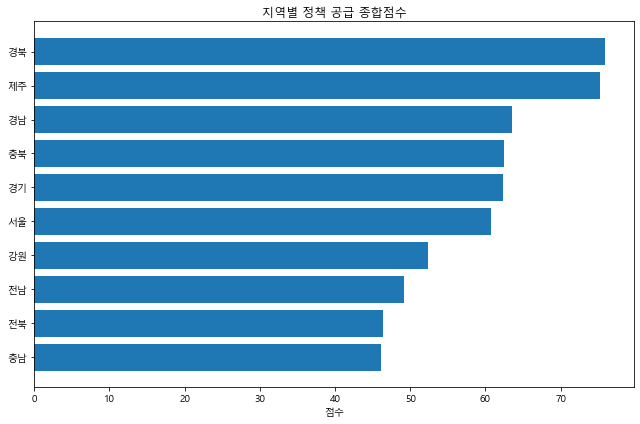

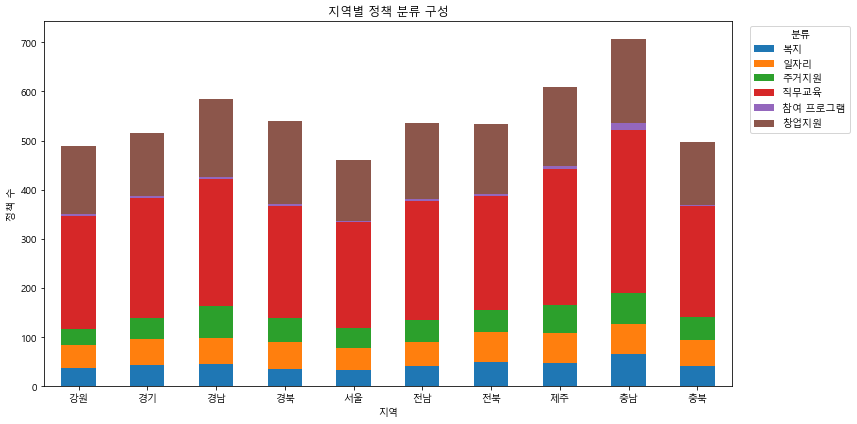

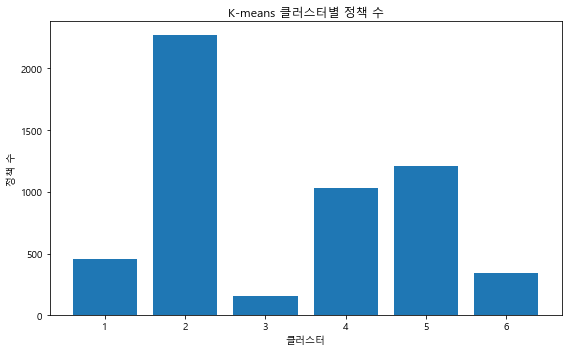

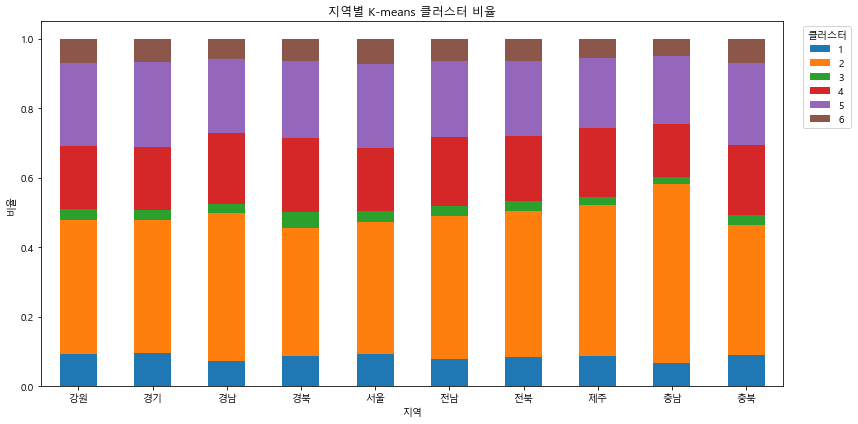

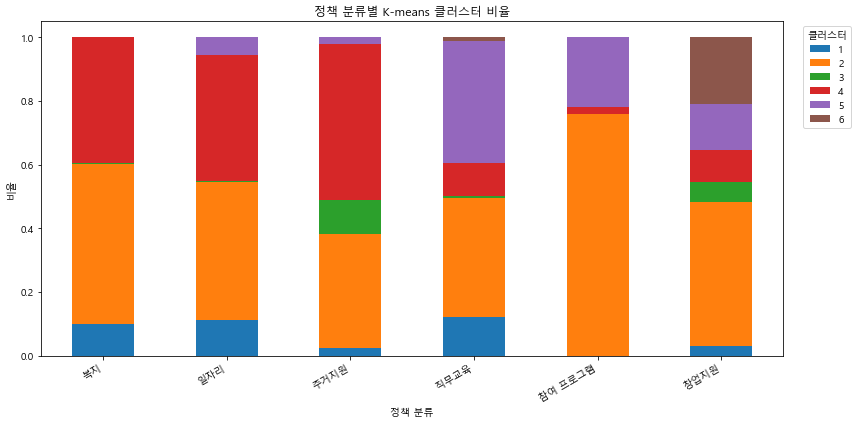

In [10]:
# 1) 지역별 정책 공급 종합점수: 02번 노트북 결과가 있을 때만 표시
region_score_path = OUTPUT_DIR / "policy_region_score_solo.csv"
if region_score_path.exists():
    region_score = pd.read_csv(region_score_path, encoding="utf-8-sig")
    if "정책공급종합점수" in region_score.columns:
        plot_df = region_score.sort_values("정책공급종합점수", ascending=True)
        plt.figure(figsize=(9, 6))
        plt.barh(plot_df["지역"], plot_df["정책공급종합점수"])
        plt.title("지역별 정책 공급 종합점수")
        plt.xlabel("점수")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "region_policy_supply_score_solo.png", dpi=200)
        plt.show()
else:
    print("02번 노트북 결과가 없어 정책공급점수 시각화는 건너뜁니다.")

# 2) 지역×정책 분류 구성
region_category = pd.crosstab(df["지역"], df[category_col])
if "기타" in region_category.columns:
    ordered_cols = [c for c in region_category.columns if c != "기타"] + ["기타"]
    region_category = region_category[ordered_cols]

region_category.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("지역별 정책 분류 구성")
plt.xlabel("지역")
plt.ylabel("정책 수")
plt.xticks(rotation=0)
plt.legend(title="분류", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "region_category_stacked_solo.png", dpi=200)
plt.show()

# 3) K-means 클러스터 크기
plot_df = cluster_size.sort_values("KMeans클러스터")
plt.figure(figsize=(8, 5))
plt.bar(plot_df["KMeans클러스터"].astype(str), plot_df["정책수"])
plt.title("K-means 클러스터별 정책 수")
plt.xlabel("클러스터")
plt.ylabel("정책 수")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "kmeans_cluster_size_solo.png", dpi=200)
plt.show()

# 4) 지역별 클러스터 비율 누적 막대그래프
region_cluster_ratio.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("지역별 K-means 클러스터 비율")
plt.xlabel("지역")
plt.ylabel("비율")
plt.xticks(rotation=0)
plt.legend(title="클러스터", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "region_kmeans_cluster_ratio_solo.png", dpi=200)
plt.show()

# 5) 분류별 클러스터 비율 누적 막대그래프
category_cluster_ratio.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("정책 분류별 K-means 클러스터 비율")
plt.xlabel("정책 분류")
plt.ylabel("비율")
plt.xticks(rotation=30, ha="right")
plt.legend(title="클러스터", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "category_kmeans_cluster_ratio_solo.png", dpi=200)
plt.show()

## 9. 결과 저장

In [11]:
df.to_csv(OUTPUT_DIR / "policy_textmining_kmeans_result_solo.csv", index=False, encoding="utf-8-sig")

print("텍스트마이닝·클러스터링 결과 저장 완료")
print("CSV 출력 폴더:", OUTPUT_DIR)
print("그림 출력 폴더:", FIGURE_DIR)
print("\n생성된 주요 CSV")
for path in sorted(OUTPUT_DIR.glob("*solo.csv")):
    print("-", path.name)
print("\n생성된 그림")
for path in sorted(FIGURE_DIR.glob("*_solo.png")):
    print("-", path.name)

텍스트마이닝·클러스터링 결과 저장 완료
CSV 출력 폴더: C:\Users\yong\Desktop\TM\tm2\textmining_solo_policy_project\textmining_solo_policy_project\outputs
그림 출력 폴더: C:\Users\yong\Desktop\TM\tm2\textmining_solo_policy_project\textmining_solo_policy_project\outputs\figures

생성된 주요 CSV
- category_kmeans_cluster_count_solo.csv
- category_kmeans_cluster_ratio_solo.csv
- category_tfidf_keywords_solo.csv
- kmeans_cluster_examples_solo.csv
- kmeans_cluster_keywords_solo.csv
- kmeans_cluster_size_solo.csv
- overall_keyword_frequency_solo.csv
- policy_category_summary_solo.csv
- policy_duplicate_diagnostics_solo.csv
- policy_issue_region_coverage_solo.csv
- policy_issue_region_pivot_solo.csv
- policy_preprocessed_solo.csv
- policy_region_category_pivot_solo.csv
- policy_region_interpretation_solo.csv
- policy_region_score_solo.csv
- policy_region_summary_solo.csv
- policy_scored_solo.csv
- policy_scoring_weights_solo.csv
- policy_textmining_kmeans_result_solo.csv
- region_keyword_frequency_solo.csv
- region_kmeans_clu

## 보고서용 방법론 요약

정책명, 정책키워드, 정책설명, 정책지원내용 등을 결합한 분석 텍스트를 대상으로 정규표현식 기반 텍스트 정제를 수행하였다. 이후 2글자 이상의 한글·영문 토큰을 추출하고, 지역명, 행정 일반어, 신청 관련 일반어, 코드성 숫자 등 분석 의미가 약한 불용어를 제거하였다. 전체 및 지역별 단어 빈도 분석을 통해 정책 텍스트에서 자주 등장하는 핵심 어휘를 확인하고, 지역별·분류별 TF-IDF 분석을 통해 각 지역과 정책 분야에서 상대적으로 두드러지는 키워드를 추출하였다. 마지막으로 정책별 TF-IDF 특징 벡터를 기반으로 K-means 클러스터링을 수행하여 유사한 정책 문서들을 군집화하고, 클러스터별 대표 키워드와 대표 정책 사례를 제시하였다. 이 분석은 텍스트 전처리, 카운트 기반 문서 표현, TF-IDF, 텍스트 시각화, 클러스터링의 수업 흐름에 맞추어 구성하였다.